# Détection d'anomalies par modèles temporels (LSTM / GRU)

Reformater les données en séquences temporelles. Entraîner un LSTM ou GRU pour prédire le prochain événement. Les événements mal prédits sont considérés comme des anomalies. Comparer avec l'Autoencoder.

## Définition et Principe

Un LSTM (Long Short-Term Memory) et un GRU (Gated Recurrent Unit) sont deux types de réseaux de neurones conçus pour traiter des données séquentielles. Contrairement à un réseau classique qui traite chaque point indépendamment, ces modèles ont une mémoire ainsi ils prennent en compte les événements précédents pour faire leur prédiction.

Pour la détection d'anomalies, le principe est le suivant : on entraîne le modèle sur du trafic normal pour qu'il apprenne à prédire le prochain événement à partir des événements précédents. Face à une anomalie, le modèle sera surpris et sa prédiction sera très différente de ce qui s'est réellement passé. Cette erreur de prédiction élevée est le signe d'une anomalie.

La différence avec l'Autoencoder est que celui-ci détecte les anomalies par reconstruction et compare ensuite au trafic normal, alors que le LSTM et GRU le fait par prédiction en se demandant si cet événement était attendu après les précédents.

## Importation des librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, f1_score, recall_score, precision_score
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version : {tf.__version__}")

2026-04-29 10:23:16.783331: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version : 2.16.2


In [2]:
chemin_CICIDS = '../Data/cicids_clean.csv'
chemin_UNSW   = '../Data/unsw_clean.csv'
chemin_LOGS   = '../Data/logs_clean.csv'

df_cicids = pd.read_csv(chemin_CICIDS, low_memory=False)
df_unsw = pd.read_csv(chemin_UNSW,low_memory=False)
df_logs = pd.read_csv(chemin_LOGS,low_memory=False)


## Fonctions utilitaires

On crée plusieurs fonctions utilitaires qui nous aideront et nous faliciterons le travail.
Tout d'abord la fonction creer_sequences transforme les données brutes en séquences temporelles. Au lieu de traiter chaque connexion indépendamment comme les modèles précédents, on crée des fenêtres glissantes, par exemple avec seq_len=10, on prend les 10 premières connexions pour prédire la 11ème, puis les connexions 2 à 11 pour prédire la 12ème. 

Les fonctions build_lstm et build_gru construisent deux architectures différentes pour traiter ces séquences. Le LSTM a une mémoire courte et une mémoire longue ce qui le rend plus précis mais plus lent. Le GRU est une version simplifiée avec un seul état interne, plus rapide et souvent aussi performant. Les deux ont la même structure soit une couche récurrente qui lit la séquence entière et produit un vecteur résumé, suivie d'une couche dense qui prédit le prochain point.

La fonction detecter_anomalies utilise le modèle entraîné pour détecter les menaces. Le modèle ayant appris uniquement sur du trafic normal, il sait bien prédire ce qui suit une séquence normale. Face à une anomalie, sa prédiction sera très différente de ce qui s'est réellement passé ensuite on mesure cet écart via l'erreur MSE et on le compare au seuil. Tout ce qui dépasse ce seuil est considéré comme une anomalie.

In [3]:
def creer_sequences(X, seq_len): # seq_len est la longueur de la fenêtre temporelle en entrée
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_len):
        X_seq.append(X[i : i + seq_len])  # fenêtre glissante de seq_len points
        y_seq.append(X[i + seq_len])      # point suivant à prédire
    return np.array(X_seq), np.array(y_seq)


def build_lstm(seq_len, n_features, units=64):  #   n_features est le nombre de features par point et units est le nombre de neurones dans la couche LST
    model = keras.Sequential([
        # couche LSTM qui lit la séquence et produit un vecteur résumé
        layers.LSTM(units, input_shape=(seq_len, n_features)),
        # couche de sortie qui prédit le prochain point 
        layers.Dense(n_features) ])
    model.compile(optimizer='adam', loss='mse')
    return model


def build_gru(seq_len, n_features, units=64):
    model = keras.Sequential([layers.GRU(units, input_shape=(seq_len, n_features)),layers.Dense(n_features)])
    model.compile(optimizer='adam', loss='mse')
    return model


def detecter_anomalies(model, X_seq, y_seq, seuil):
    predictions = model.predict(X_seq, verbose=0)   #ce que le modèle prédit
    erreurs = np.mean((y_seq - predictions) ** 2, axis=1)  # écart entre prédit et réel
    return (erreurs > seuil).astype(int), erreurs           # 1 pour anomalie si erreur est supérieure au seuil


## Dataset 1 : CIC-IDS-2017

### 1.1 Préparation et création des séquences

On remet en former les données en séquences de longueur seq_len1=10 ainsi chaque séquence représente 10 connexions consécutives et le modèle doit prédire la 11ème.

In [8]:
seq_len1 = 5  # longueur de la fenêtre temporelle

# Préparation features / label
X = df_cicids.drop(columns=['Label']).select_dtypes(include=[np.number])
y_cicids = (df_cicids['Label'] != 'BENIGN').astype(int)
X = X.fillna(0).replace([np.inf, -np.inf], 0)
X_scaled = StandardScaler().fit_transform(X)

# séparation normaux et attaques
X_normal  = X_scaled[y_cicids == 0]
X_attaque = X_scaled[y_cicids == 1]

# échantillon 
X_normal = X_normal[np.random.choice(len(X_normal), size=20000, replace=False)]

# création des séquences sur les normaux uniquement
X_seq, y_seq = creer_sequences(X_normal, seq_len1)

#split train et test
X_train, X_test_seq, y_train, y_test_seq = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42)

#séquences d'attaques pour le test
X_att_seq, y_att_seq = creer_sequences( X_attaque[np.random.choice(len(X_attaque), size=5000, replace=False)], seq_len1)

# Jeu de test final avec des normaux et attaques
n = len(X_test_seq)
X_test_final = np.vstack([X_test_seq[:n], X_att_seq[:n]])
y_test_final = np.vstack([y_test_seq[:n], y_att_seq[:n]])
labels_test  = np.array([0] * n + [1] * n)

print(f"Train séquences : {X_train.shape}")
print(f"Test séquences : {X_test_final.shape}")

Train séquences : (15996, 5, 79)
Test séquences : (7998, 5, 79)


### 1.2 Entraînement LSTM et GRU

In [9]:
n_features = X_train.shape[2]  # nombre de features
resultats_cicids = []

for nom, model in [('LSTM', build_lstm(seq_len1, n_features)),('GRU',  build_gru(seq_len1,  n_features))]:
    print(f"\nModèle : {nom}")

    # entraînement sur les séquences normales uniquement
    history = model.fit(X_train, y_train,epochs=50,batch_size=256,validation_split=0.1,verbose=0)

    # seuil même formule que précédemment
    pred_train = model.predict(X_train, verbose=0)
    erreurs_train = np.mean((y_train - pred_train) ** 2, axis=1)
    seuil = erreurs_train.mean() + 2 * erreurs_train.std()

    pred, erreurs = detecter_anomalies(model, X_test_final, y_test_final, seuil)
    auc = roc_auc_score(labels_test, erreurs)

    print(classification_report(labels_test, pred, target_names=['Normal', 'Attaque']))
    print(f"AUC-ROC : {auc:.3f} et seuil : {seuil:.4f}")

    resultats_cicids.append({'Modèle' : nom, 'history': history,'erreurs': erreurs, 'pred': pred,'seuil'  : seuil,  'auc' : auc})


Modèle : LSTM
              precision    recall  f1-score   support

      Normal       0.50      0.99      0.66      3999
     Attaque       0.00      0.00      0.00      3999

    accuracy                           0.50      7998
   macro avg       0.25      0.50      0.33      7998
weighted avg       0.25      0.50      0.33      7998

AUC-ROC : 0.419 et seuil : 23.6100

Modèle : GRU
              precision    recall  f1-score   support

      Normal       0.50      0.99      0.66      3999
     Attaque       0.00      0.00      0.00      3999

    accuracy                           0.50      7998
   macro avg       0.25      0.50      0.33      7998
weighted avg       0.25      0.50      0.33      7998

AUC-ROC : 0.486 et seuil : 26.3196


Les résultats sont assez mauvais malgré l'essaie d'ajustements on a un recall de 0% et f1 nul sur les attaques pour les deux modèles.
Les seuils restent aberrants (23.61 et 26.32) ce qui confirme que le problème n'est pas réglable par des ajustements de paramètres. Le modèle fait de si grandes erreurs sur les données normales qu'aucune attaque ne dépasse le seuil.
L'AUC du GRU remonte légèrement à 0.486 contre 0.286 avant, mais reste sous 0.5 ainsi le modèle fait toujours pire qu'un tirage aléatoire.
La conclusion est que le dataset CICIDS2017 n'est pas un dataset temporel. Les connexions n'ont pas d'ordre séquentiel naturel ainsi une connexion à l'instant t n'a aucune relation avec celle à l'instant t+1. L'autoencoder avec son AUC de 0.983 reste de loin le meilleur modèle sur ce dataset.

### 1.3 Courbes d'apprentissage

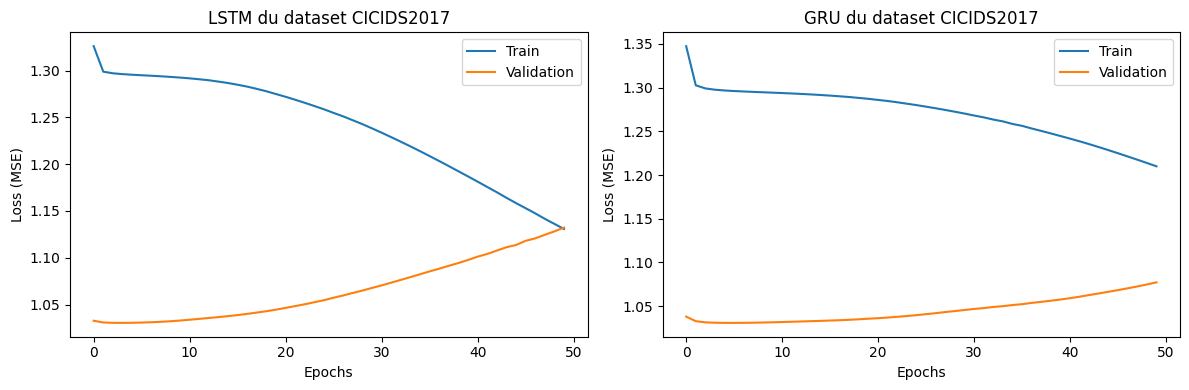

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for ax, res in zip([ax1, ax2], resultats_cicids):
    ax.plot(res['history'].history['loss'], label='Train')
    ax.plot(res['history'].history['val_loss'], label='Validation')
    ax.set(title=f"{res['Modèle']} du dataset CICIDS2017", xlabel='Epochs', ylabel='Loss (MSE)')
    ax.legend()

plt.tight_layout()
plt.show()

Sur les deux graphes, l'erreur de reconstruction de validation descend rapidement et se stabilise autour de 1.05, tandis que l'erreur de reconstruction d'entraînement reste très haute et continue de descendre lentement, elles vont dans des directions opposées. C'est exactement l'inverse du comportement normal où train et validation devraient descendre ensemble.
Cette observation confirme que LSTM et GRU ne sont pas adaptés à ce dataset.

### 1.4 Distribution des erreurs de prédiction

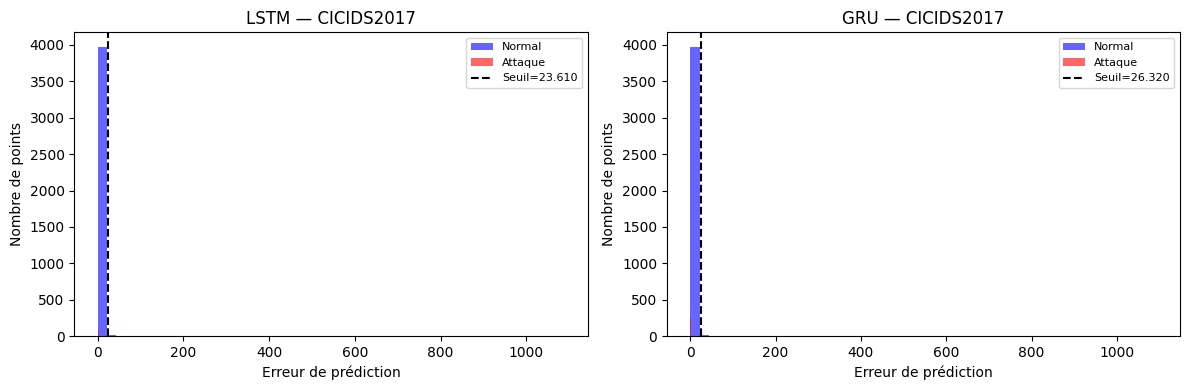

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for ax, res in zip([ax1, ax2], resultats_cicids):
    ax.hist(res['erreurs'][labels_test == 0], bins=50, alpha=0.6, label='Normal',  color='blue')
    ax.hist(res['erreurs'][labels_test == 1], bins=50, alpha=0.6, label='Attaque', color='red')
    ax.axvline(res['seuil'], color='black', linestyle='--', label=f'Seuil={res["seuil"]:.3f}')
    ax.set(title=f"{res['Modèle']} — CICIDS2017", xlabel='Erreur de prédiction', ylabel='Nombre de points')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

On remarque que tous les points normaux comme attaques  sont concentrés à 0 sur l'axe des erreurs, tandis que le seuil est placé un peu après complètement hors de la distribution réelle des données.
Cela signifie que ni les normaux ni les attaques ne dépassent jamais ce seuil, donc le modèle classe tout comme normal et d'où le recall de 0% sur les attaques. 


## Dataset 2 : UNSW-NB15

### 2.1 Préparation et création des séquences

In [12]:
seq_len2=10
X = df_unsw.drop(columns=['Label']).select_dtypes(include=[np.number])
y_unsw = df_unsw['Label'].values
X = X.fillna(0).replace([np.inf, -np.inf], 0)
X_scaled = StandardScaler().fit_transform(X)

X_normal  = X_scaled[y_unsw == 0]
X_attaque = X_scaled[y_unsw == 1]

X_normal = X_normal[np.random.choice(len(X_normal), size=20000, replace=False)]

X_seq, y_seq = creer_sequences(X_normal, seq_len2)
X_train, X_test_seq, y_train, y_test_seq = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42)

X_att_seq, y_att_seq = creer_sequences(
    X_attaque[np.random.choice(len(X_attaque), size=5000, replace=False)], seq_len2)

n = len(X_test_seq)
X_test_final = np.vstack([X_test_seq[:n], X_att_seq[:n]])
y_test_final = np.vstack([y_test_seq[:n], y_att_seq[:n]])
labels_test  = np.array([0] * n + [1] * n)

print(f"Train séquences : {X_train.shape}")
print(f"Test séquences : {X_test_final.shape}")

Train séquences : (15992, 10, 44)
Test séquences : (7996, 10, 44)


### 2.2 Entraînement LSTM et GRU

In [17]:
n_features = X_train.shape[2]
resultats_unsw = []

for nom, model in [('LSTM', build_lstm(seq_len2, n_features)),('GRU',  build_gru(seq_len2,  n_features))]:
    print(f"\nModèle : {nom}")

    history = model.fit(X_train, y_train,epochs=20,batch_size=256,validation_split=0.1,verbose=0)

    pred_train = model.predict(X_train, verbose=0)
    erreurs_train = np.mean((y_train - pred_train) ** 2, axis=1)
    seuil = erreurs_train.mean() + 2 * erreurs_train.std()

    pred, erreurs = detecter_anomalies(model, X_test_final, y_test_final, seuil)
    auc = roc_auc_score(labels_test, erreurs)

    print(classification_report(labels_test, pred, target_names=['Normal', 'Attaque']))
    print(f"AUC-ROC : {auc:.3f} et seuil : {seuil:.4f}")

    resultats_unsw.append({'Modèle' : nom, 'history': history,'erreurs': erreurs, 'pred': pred,'seuil'  : seuil,  'auc' : auc})


Modèle : LSTM
              precision    recall  f1-score   support

      Normal       0.53      0.99      0.69      3998
     Attaque       0.92      0.13      0.23      3998

    accuracy                           0.56      7996
   macro avg       0.73      0.56      0.46      7996
weighted avg       0.73      0.56      0.46      7996

AUC-ROC : 0.960 et seuil : 7.6792

Modèle : GRU
              precision    recall  f1-score   support

      Normal       0.52      0.99      0.68      3998
     Attaque       0.87      0.07      0.13      3998

    accuracy                           0.53      7996
   macro avg       0.69      0.53      0.40      7996
weighted avg       0.69      0.53      0.40      7996

AUC-ROC : 0.953 et seuil : 8.1221


Les résultats sur ce dataset sont  meilleurs que sur CICIDS et confirment que ce dataset a une structure temporelle exploitable.
Les AUC de 0.958 pour le LSTM et 0.954 pour le GRU sont bonnes et comparables à l'Autoencoder légère (0.998) ainsi les deux modèles séparent très bien les classes en termes de scores continus. Cependant le recall reste faible avec seulement 10% pour le LSTM et 7% pour le GRU à cause d'un seuil encore trop élevé (7.63 et 8.17). En revanche la précision est très bonne (0.90 et 0.87) 
Entre les deux, le LSTM est légèrement supérieur avec un meilleur recall et f1 et comparé à l'Autoencoder qui atteignait un recall de 100% sur ce dataset, les modèles temporels restent moins bons .

### 2.3 Courbes d'apprentissage

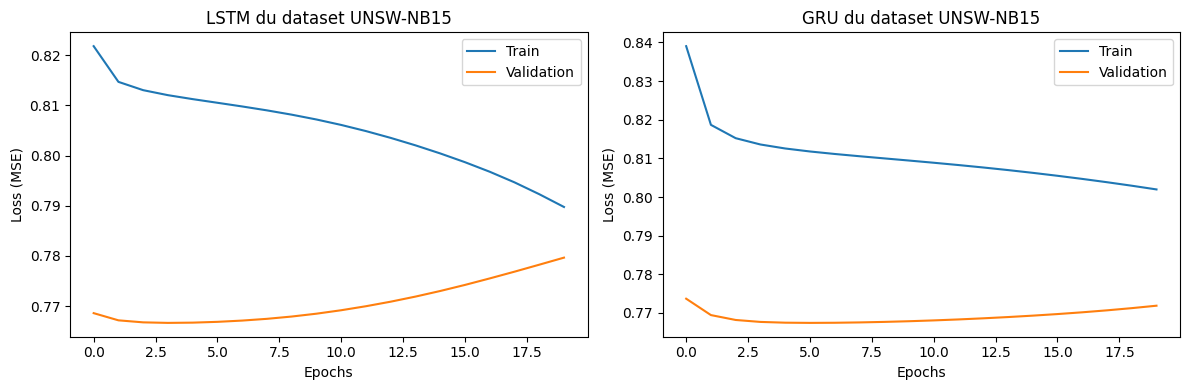

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for ax, res in zip([ax1, ax2], resultats_unsw):
    ax.plot(res['history'].history['loss'], label='Train')
    ax.plot(res['history'].history['val_loss'], label='Validation')
    ax.set(title=f"{res['Modèle']} du dataset UNSW-NB15", xlabel='Epochs', ylabel='Loss (MSE)')
    ax.legend()

plt.tight_layout()
plt.show()

On rencontre le même soucis que sur l'ancien dataset en effet les deux courbes montrent le même problème de surapprentissage l'erreur de reconstruction de validation remonte après les premières epochs tandis que l'erreur de reconstruction d'entraînement continue de descendre. Les deux courbes divergent progressivement.
Cependant le surapprentissage est moins sévère que sur l'ancien dataset l'erreur de reconstruction restent dans des plages similaires (0.77-0.82) et l'écart entre train et validation est plus faible. 
Le GRU se stabilise mieux que le LSTM car sa courbe de validation est plus plate après l'epoch 5.

### 2.4 Distribution des erreurs de prédiction

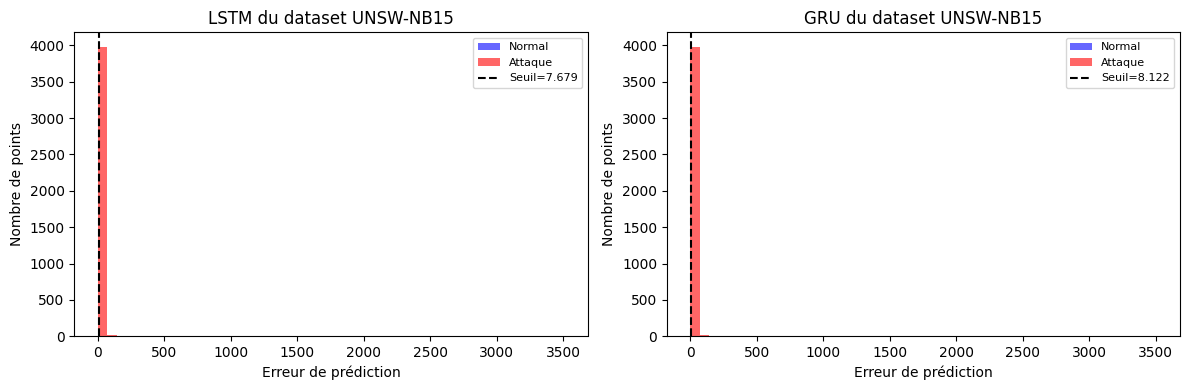

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for ax, res in zip([ax1, ax2], resultats_unsw):
    ax.hist(res['erreurs'][labels_test == 0], bins=50, alpha=0.6, label='Normal',  color='blue')
    ax.hist(res['erreurs'][labels_test == 1], bins=50, alpha=0.6, label='Attaque', color='red')
    ax.axvline(res['seuil'], color='black', linestyle='--', label=f'Seuil={res["seuil"]:.3f}')
    ax.set(title=f"{res['Modèle']} du dataset UNSW-NB15", xlabel='Erreur de prédiction', ylabel='Nombre de points')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

De même ici tous les points sont concentrés à 0 tandis que le seuil est placé bien loin de la distribution réelle.
Cependant on distingue quelques points rouges qui dépassent légèrement vers la droite ce sont les 10% d'attaques détectées qu'on voyait dans le classification report. Les attaques les plus atypiques ont des erreurs légèrement plus élevées que les normaux, mais pas assez pour dépasser le seuil en masse.
Un seuil plus bas permettrait de détecter beaucoup plus d'attaques.


## Dataset 3 : Cybersecurity Threat Detection Logs

### 3.1 Préparation et création des séquences

In [20]:
seq_len3=10
# Encodage des colonnes catégorielles
df_enc = df_logs.copy()
for col in ['protocol', 'action', 'log_type']:
    if col in df_enc.columns:
        df_enc[col + '_enc'] = LabelEncoder().fit_transform(df_enc[col].astype(str))

features = ['bytes_transferred'] + [c for c in df_enc.columns if c.endswith('_enc')]
X = df_enc[features].fillna(0)
y_logs = (df_logs['threat_label'] != 'benign').astype(int)
X_scaled = StandardScaler().fit_transform(X)

X_normal  = X_scaled[y_logs == 0]
X_attaque = X_scaled[y_logs == 1]

# echantillon réduit pour les Logs
X_normal = X_normal[np.random.choice(len(X_normal), size=20000, replace=False)]

X_seq, y_seq = creer_sequences(X_normal, seq_len3)
X_train, X_test_seq, y_train, y_test_seq = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42)

X_att_seq, y_att_seq = creer_sequences(
    X_attaque[np.random.choice(len(X_attaque), size=5000, replace=False)], seq_len3)

n = len(X_test_seq)
X_test_final = np.vstack([X_test_seq[:n], X_att_seq[:n]])
y_test_final = np.vstack([y_test_seq[:n], y_att_seq[:n]])
labels_test  = np.array([0] * n + [1] * n)

print(f"Train séquences : {X_train.shape}")
print(f"Test  séquences : {X_test_final.shape}")

Train séquences : (15992, 10, 4)
Test  séquences : (7996, 10, 4)


### 3.2 Entraînement LSTM et GRU

In [21]:
n_features = X_train.shape[2]
resultats_logs = []

for nom, model in [('LSTM', build_lstm(seq_len3, n_features, units=32)),('GRU',  build_gru(seq_len3,  n_features, units=32))]:
    print(f"\nModèle : {nom}")

    history = model.fit(X_train, y_train,epochs=15,batch_size=512,validation_split=0.1,verbose=0)

    pred_train = model.predict(X_train, verbose=0)
    erreurs_train = np.mean((y_train - pred_train) ** 2, axis=1)
    seuil = erreurs_train.mean() + 2 * erreurs_train.std()

    pred, erreurs = detecter_anomalies(model, X_test_final, y_test_final, seuil)
    auc = roc_auc_score(labels_test, erreurs)

    print(classification_report(labels_test, pred, target_names=['Normal', 'Anomalie']))
    print(f"AUC-ROC : {auc:.3f} et seuil : {seuil:.4f}")

    resultats_logs.append({'Modèle' : nom, 'history': history,'erreurs': erreurs, 'pred': pred,'seuil'  : seuil,  'auc' : auc})


Modèle : LSTM
              precision    recall  f1-score   support

      Normal       0.50      0.97      0.66      3998
    Anomalie       0.53      0.03      0.06      3998

    accuracy                           0.50      7996
   macro avg       0.51      0.50      0.36      7996
weighted avg       0.51      0.50      0.36      7996

AUC-ROC : 0.460 et seuil : 1.6770

Modèle : GRU
              precision    recall  f1-score   support

      Normal       0.50      0.97      0.66      3998
    Anomalie       0.55      0.03      0.06      3998

    accuracy                           0.50      7996
   macro avg       0.53      0.50      0.36      7996
weighted avg       0.53      0.50      0.36      7996

AUC-ROC : 0.459 et seuil : 1.6777


Les résultats sur Logs donnent un f1 de 0.06 sur les anomalies et AUC de 0.46 en dessous de 0.5, soit pire qu'un modèle aléatoire pour les deux modèles.
C'est exactement le même constat que pour l'Autoencoder sur ce dataset car avec seulement 4 features, ni le LSTM ni le GRU ne peuvent apprendre de patterns temporels significatifs. La séquence de 10 connexions consécutives ne porte aucune information utile car les features disponibles ne distinguent pas le trafic normal des anomalies.

### 3.3 Courbes d'apprentissage

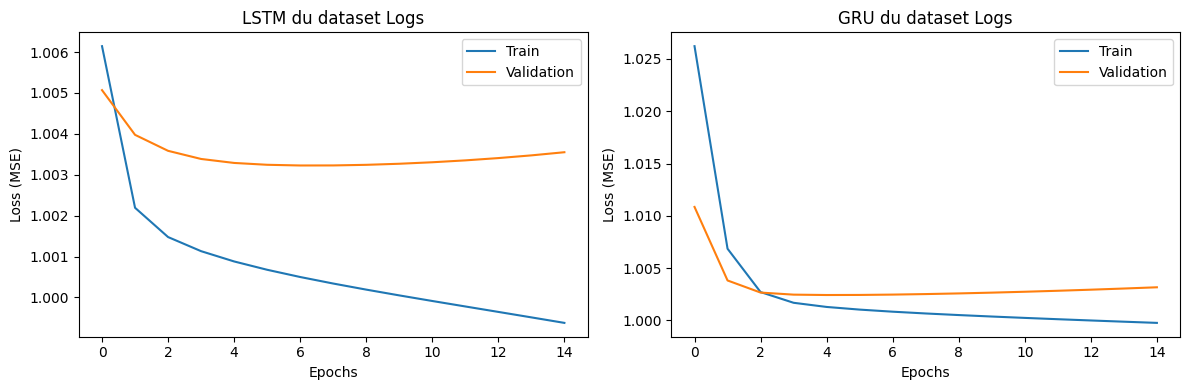

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for ax, res in zip([ax1, ax2], resultats_logs):
    ax.plot(res['history'].history['loss'],  label='Train')
    ax.plot(res['history'].history['val_loss'], label='Validation')
    ax.set(title=f"{res['Modèle']} du dataset Logs", xlabel='Epochs', ylabel='Loss (MSE)')
    ax.legend()

plt.tight_layout()
plt.show()

Les deux courbes montrent un surapprentissage classique car l'erreur de reconstruction d'entraînement continue de descendre jusqu'à 1.000 tandis que la validation se stabilise puis remonte légèrement après l'epoch 2.
Ce qui est frappant c'est que les deux erreur de reconstruction restent très proches de 1.0 tout au long de l'entraînement ce qui confirme que le modèle n'apprend pratiquement rien car avec seulement 4 features, il n'y a pas assez d'information pour que le LSTM ou le GRU construise une représentation temporelle utile du trafic normal.
Le GRU se comporte légèrement mieux sa validation se stabilise plus tôt et l'écart avec le train est plus faible, mais les deux modèles échouent .

### 3.4 Distribution des erreurs de prédiction

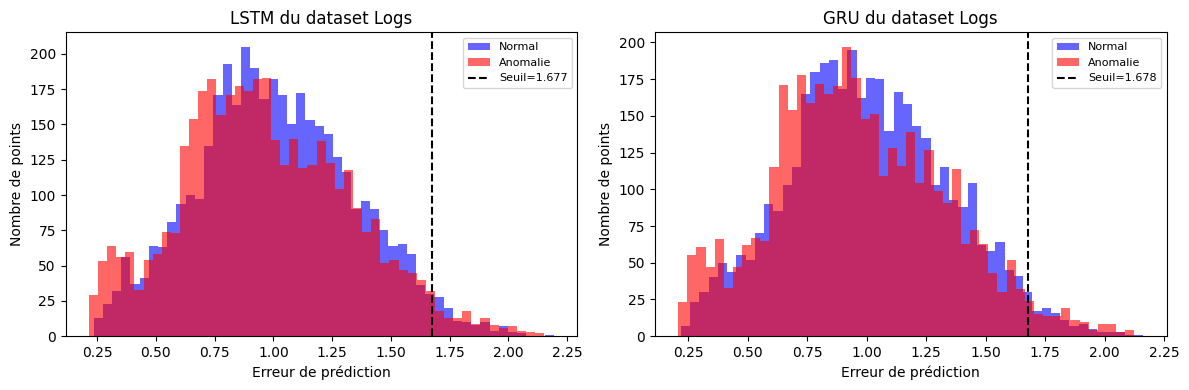

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for ax, res in zip([ax1, ax2], resultats_logs):
    ax.hist(res['erreurs'][labels_test == 0], bins=50, alpha=0.6, label='Normal',   color='blue')
    ax.hist(res['erreurs'][labels_test == 1], bins=50, alpha=0.6, label='Anomalie', color='red')
    ax.axvline(res['seuil'], color='black', linestyle='--', label=f'Seuil={res["seuil"]:.3f}')
    ax.set(title=f"{res['Modèle']} du dataset Logs", xlabel='Erreur de prédiction', ylabel='Nombre de points')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

On remarque que les distributions normal  et anomalie se chevauchent parfaitement les deux ont exactement la même forme et centrée autour de 1.0. Le modèle attribue des erreurs de prédiction identiques aux connexions normales et aux anomalies, ce qui rend toute séparation impossible.


## Bilan

En conclusion l'approche temporelle par LSTM et GRU donne des résultats assez contrastés selon les datasets, et confirme que la qualité et la structure des données sont déterminantes.
Sur le dataset CICIDS2017, les deux modèles échouent complètement avec un recall de 0% et des AUC inférieures à 0.5. Le surapprentissage sévère observé sur les courbes d'apprentissage explique ce résultat en effet les connexions de ce dataset ne sont pas ordonnées temporellement, donc demander au modèle de prédire la prochaine connexion à partir des précédentes n'a aucun sens. L'Autoencoder reste de loin supérieur sur ce dataset.
Sur le dataset UNSW-NB15, les résultats sont meilleurs avec des AUC de 0.954 et 0.958 pour le GRU et le LSTM. Cela confirme que ce dataset a une structure temporelle exploitable car les attaques génèrent des erreurs de prédiction plus élevées que le trafic normal. Cependant le recall reste faible (7-10%) mais l'Autoencoder  avec son recall de 100% reste le meilleur modèle sur ce dataset.
Sur le dataset Logs, il s'agit d'un échec identique à tous les modèles testés depuis le début du projet. Les distributions des erreurs de prédiction sont parfaitement superposées pour les normaux et les anomalies car les 4 features disponibles ne portent aucune information temporelle exploitable.
En conclusion, le LSTM et le GRU ne s'imposent pas comme meilleurs que l'Autoencoder sur ces trois datasets.